Département de génie électrique - Polytechnique Montréal

Analyse des signaux - ELE2700

TP4 version 4.0: A2025

---
Numéro d'équipe: #102

Noms, prénoms et matricules:

- Machraoui, Simon : 2487824

- Beaumier, Édouard : 2087482



## $\color{#03fc9d}{\textbf{Exercice 3, devoir (10pt/20):}}$

Nous considérons maintenant un signal *chirp exponentiel* dont l'expression est donnée ci-dessous :

$$
x(t) = \text{cos}\left(\omega_0\left(\frac{T(k^{t/T}-1)}{\ln(k)}\right)\right),
$$
où :
*   $\omega_0$ = $2\pi$ Hz;
*   $k$ = e
*   $T$ = 1 s;
*   $f_s$ = 1000 Hz.




In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Paramètres du signal chirp
f0 = 10  # Fréquence de départ du chirp (en Hz)
f1 = 100  # Fréquence finale du chirp (en Hz)
T = 1.0  # Durée du signal chirp (en secondes)

def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
signal = chirp_signal(f0, f1, t, T)

$\color{orange}{\text{a) [Photos dans case texte]}}$ Donner l'expression analytique d'auto-corrélation d'un signal *chirp* avec lui-même. Prendre les paramètres suivants : $\color{red}{\textbf{(3pt/20)}}$

*   $\omega_0$ = $2\pi$ Hz;
*   $k$ = e;
*   $T$ = 1 s.

Ainsi, donner l'expression d'autocorrélation du signal:

$$
\cos\left(2\pi \mathrm{e}^t\right).
$$

Utiliser les trois premiers termes du développement en série de Taylor pour approximer $\mathrm{e}^t$ comme au TP-3.


![Page 1](TP4_Demarche_1.jpg)
![Page 2](TP4_Demarche_2.jpg)
![Page 3](TP4_Demarche_3.jpg)
![Page 4](TP4_Demarche_4.jpg)
![Page 5](TP4_Demarche_5.jpg)

# <font color='green'> Analyse d'un signal radar issu d'un environnement et d'une cible inconnus </font>


À partir de maintenant, nous nous plaçons dans le contexte de simulation d'un radar standard. Le signal suit donc le chemin suivant: aller jusqu'à une cible, réflexion depuis la cible et retour vers le radar. L'aller et le retour se fait dans un milieu de propagation. Ce milieu sera simulé par un environnment boîte noire. Cet aller-retour est effectué pour chaque cible présente.

Télécharger sur `Moodle` le fichier `blackbox_tp4.so` et rouler la commande suivante.

In [21]:
from google.colab import files

S'assurer d'avoir téléchargé le fichier `blackbox_tp4.so` avant l'étape suivante. Le sélectionner en appuyant sur `Choose Files`.

In [22]:
uploaded = files.upload() # Décommenter la première fois que vous roulez le code pour importer votre fichier blackbox_tp4 (ne pas oublier de recommenter un fois cela fait!)

Saving blackbox_tp4.so to blackbox_tp4 (1).so


**Vérifier** que le fichier a bien été téléchargé dans l'environnement actuel. Si jamais vous voulez retirer un fichier, utiliser la commande suivante:

In [23]:
!ls -lh
# !rm blackbox_tp4.so  #Commande pour retirer un fichier, si nécessaire. Laisser en commentaire.

total 468K
-rw-r--r-- 1 root root 231K Nov 11 15:51 'blackbox_tp4 (1).so'
-rw-r--r-- 1 root root 231K Nov 11 15:45  blackbox_tp4.so
drwxr-xr-x 1 root root 4.0K Nov  7 14:30  sample_data


Une fois le fichier `blackbox_tp4` importé, rouler la commande suivante:

In [24]:
import blackbox_tp4

Le fichier `blackbox_tp4` contient l'exécutable de la fonction boîte noire `blackbox1`, que nous considérons être un milieu de propagation contenant de l'air. La fonction accepte les arguments suivants:


*   Argument 1: signal d'entrée.

Elle retourne le signal modifié dû à son passage dans le milieu de propagation.
Voici un exemple d'utilisation:

`blackbox_tp4.blackbox1(signal)`

$\color{orange}{\text{b) [code]}}$ Avec l'aide de la boîte noire fournie : Injecter le signal *chirp exponentiel* (signal décrit dans la case de code au début de l'exercice 3 où $\omega_0$ = $2\pi$ Hz, $k$ = e, $T$ = 1 s) dans la boîte noire et évaluer l'inter-corrélation entre le signal *chirp exponentiel* et sa sortie. $\color{red}{\textbf{(1pt/20)}}$

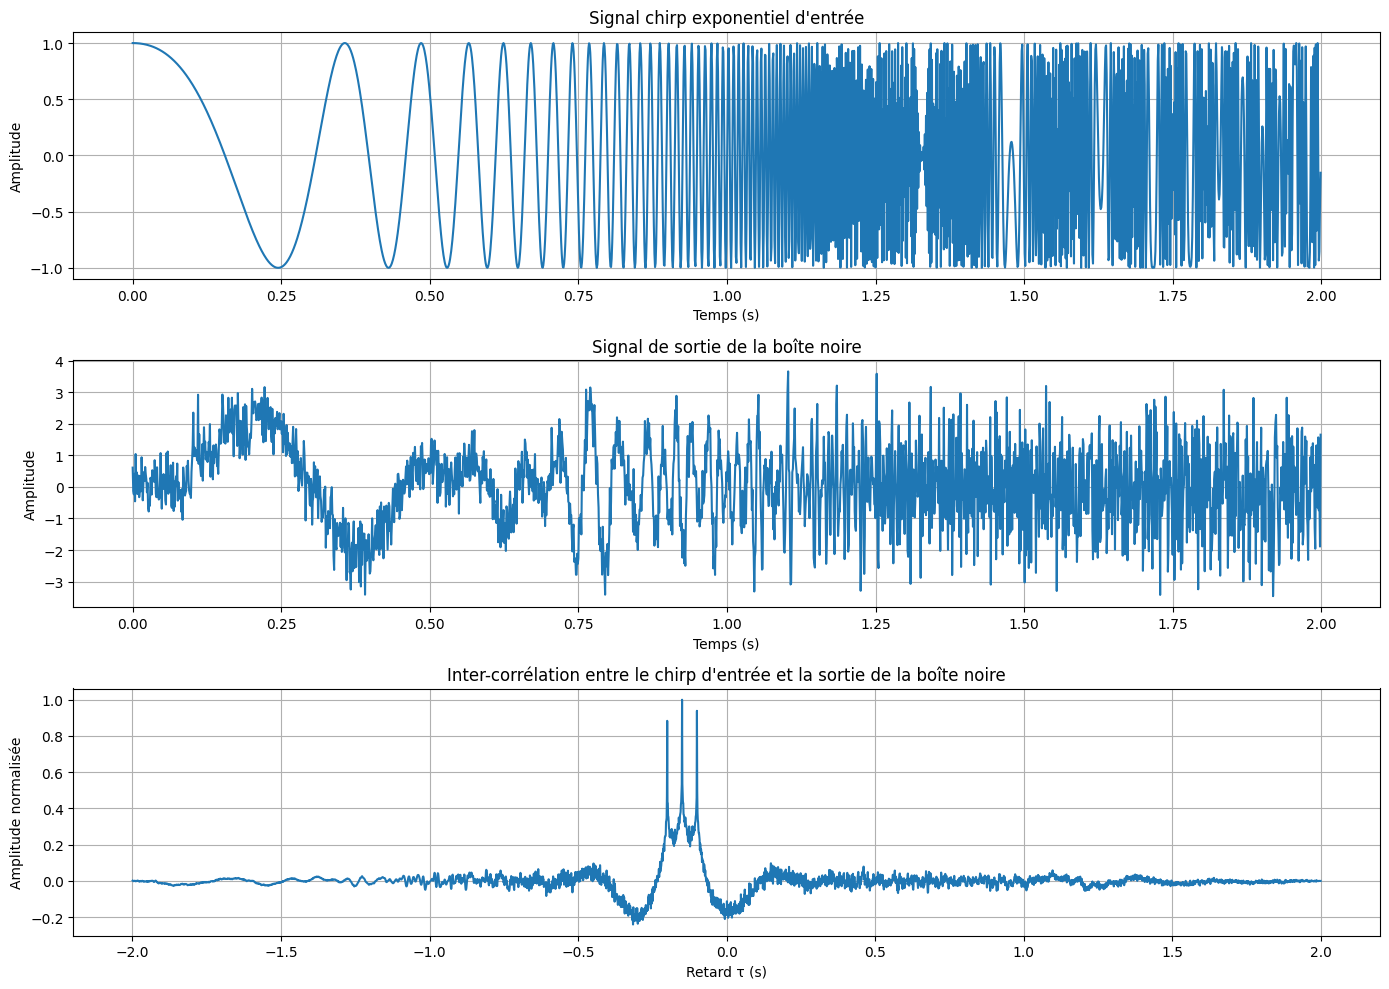

Longueur du signal d'entrée: 2000 échantillons
Longueur du signal de sortie: 2000 échantillons
Position du maximum d'inter-corrélation: -0.150000 s


In [33]:
# Écrire votre code ici pour b)
# Imports nécessaires
import numpy as np
import matplotlib.pyplot as plt
import blackbox_tp4

def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
chirp_input = chirp_signal(f0, f1, t, T)

chirp_output =  blackbox_tp4.blackbox1(chirp_input)

Rxy = np.correlate(signal, chirp_output, mode='full')

Rxy_normalized = Rxy / np.max(np.abs(Rxy))

dt = 1/fs

lags = np.arange(-len(chirp_input)+1, len(chirp_output)) * dt

plt.figure(figsize=(14, 10))

# Signal d'entrée (chirp)
plt.subplot(3, 1, 1)
plt.plot(t, chirp_input)
plt.title("Signal chirp exponentiel d'entrée")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# Signal de sortie de la boîte noire
plt.subplot(3, 1, 2)
plt.plot(t, chirp_output)
plt.title("Signal de sortie de la boîte noire")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# Inter-corrélation normalisée
plt.subplot(3, 1, 3)
plt.plot(lags, Rxy_normalized)
plt.title("Inter-corrélation entre le chirp d'entrée et la sortie de la boîte noire")
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Longueur du signal d'entrée: {len(chirp_input)} échantillons")
print(f"Longueur du signal de sortie: {len(chirp_output)} échantillons")
print(f"Position du maximum d'inter-corrélation: {lags[np.argmax(Rxy_normalized)]:.6f} s")



$\color{orange}{\text{c) [code et interprétation]}}$  Afficher sur le même graphique le signal *chirp exponentiel* d'entrée, le signal en sortie de la boîte noire, le signal d'auto-corrélation du *chirp exponentiel* et le signal d'inter-corrélation entre *chirp exponentiel* et la sortie. Expliquer pourquoi l'inter-corrélation se déplace à gauche ou à droite (selon ce qui est observeé) en comparaison à l'auto-corrélation. $\color{red}{\textbf{(3pt/20)}}$

Maximum d'auto-corrélation à τ = 0.000000 s
Maximum d'inter-corrélation à τ = -0.150000 s


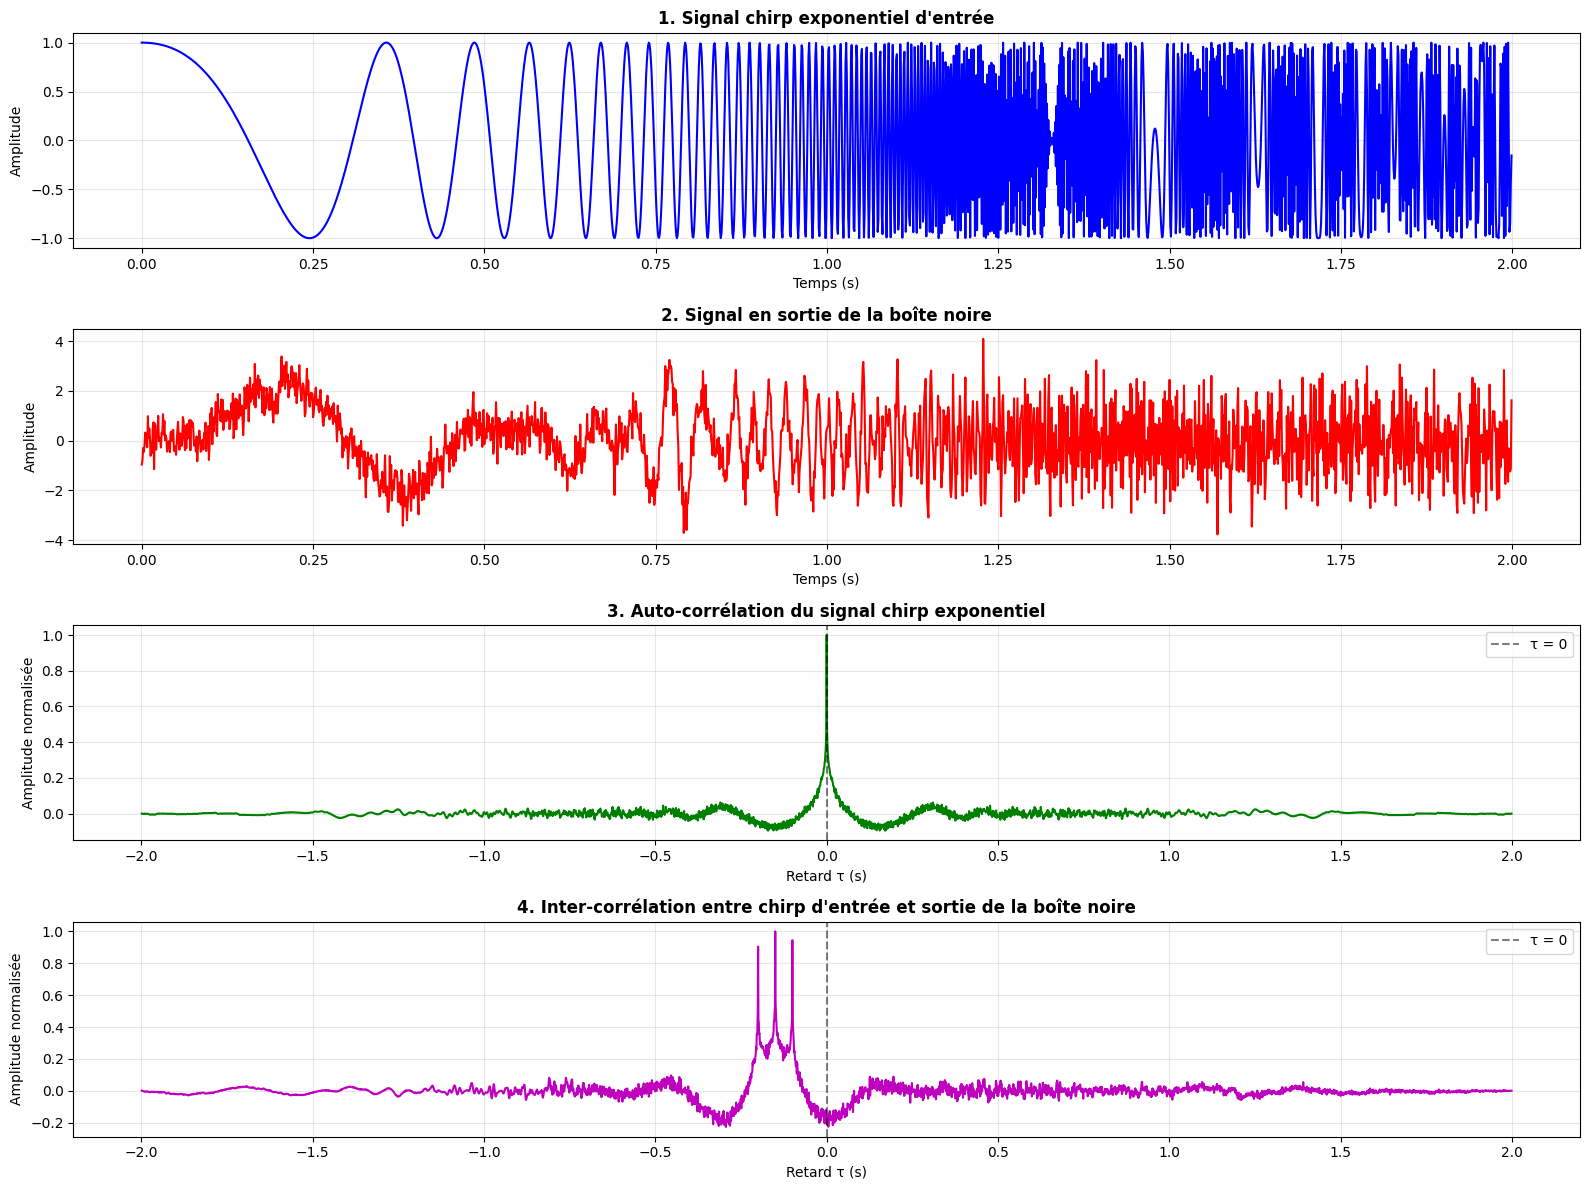

Maximum d'auto-corrélation à τ = 0.000000 s
Maximum d'inter-corrélation à τ = -0.150000 s

Décalage (délai) = -0.150000 s
Décalage en échantillons : -150 échantillons

Nombre de pics détectés (cibles potentielles) : 3
Positions des pics (délais) :
  Cible 1: τ = -0.200000 s, amplitude = 0.905
  Cible 2: τ = -0.150000 s, amplitude = 1.000
  Cible 3: τ = -0.100000 s, amplitude = 0.945


In [36]:
# Écrire votre code ici pour c)
def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
chirp_input = chirp_signal(f0, f1, t, T)

chirp_output = blackbox_tp4.blackbox1(chirp_input)

# AUTO-CORRÉLATION du signal chirp
Rxx = np.correlate(chirp_input, chirp_input, mode='full')
Rxx_normalized = Rxx / np.max(np.abs(Rxx))

#INTER-CORRÉLATION entre le signal d'entrée et la sortie
Rxy = np.correlate(chirp_input, chirp_output, mode='full')
Rxy_normalized = Rxy / np.max(np.abs(Rxy))

dt = 1/fs
lags_xx = np.arange(-len(chirp_input)+1, len(chirp_input)) * dt  # Pour auto-corrélation
lags_xy = np.arange(-len(chirp_input)+1, len(chirp_output)) * dt  # Pour inter-corrélation

plt.figure(figsize=(16, 12))

# Signal chirp exponentiel d'entrée
plt.subplot(4, 1, 1)
plt.plot(t, chirp_input, 'b-', linewidth=1.5)
plt.title("1. Signal chirp exponentiel d'entrée", fontsize=12, fontweight='bold')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Signal en sortie de la boîte noire
plt.subplot(4, 1, 2)
plt.plot(t, chirp_output, 'r-', linewidth=1.5)
plt.title("2. Signal en sortie de la boîte noire", fontsize=12, fontweight='bold')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Auto-corrélation du signal chirp
plt.subplot(4, 1, 3)
plt.plot(lags_xx, Rxx_normalized, 'g-', linewidth=1.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='τ = 0')
plt.title("3. Auto-corrélation du signal chirp exponentiel", fontsize=12, fontweight='bold')
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True, alpha=0.3)
plt.legend()

max_idx_xx = np.argmax(Rxx_normalized)
max_lag_xx = lags_xx[max_idx_xx]
print(f"Maximum d'auto-corrélation à τ = {max_lag_xx:.6f} s")

# Inter-corrélation entre chirp et sortie
plt.subplot(4, 1, 4)
plt.plot(lags_xy, Rxy_normalized, 'm-', linewidth=1.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='τ = 0')
plt.title("4. Inter-corrélation entre chirp d'entrée et sortie de la boîte noire", fontsize=12, fontweight='bold')
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True, alpha=0.3)
plt.legend()

max_idx_xy = np.argmax(Rxy_normalized)
max_lag_xy = lags_xy[max_idx_xy]
print(f"Maximum d'inter-corrélation à τ = {max_lag_xy:.6f} s")

plt.tight_layout()
plt.show()

print(f"Maximum d'auto-corrélation à τ = {max_lag_xx:.6f} s")
print(f"Maximum d'inter-corrélation à τ = {max_lag_xy:.6f} s")
print(f"\nDécalage (délai) = {max_lag_xy - max_lag_xx:.6f} s")
print(f"Décalage en échantillons : {int((max_lag_xy - max_lag_xx) * fs)} échantillons")

# Trouver tous les pics significatifs dans l'inter-corrélation
from scipy.signal import find_peaks
peaks, properties = find_peaks(Rxy_normalized, height=0.3, distance=50)
print(f"\nNombre de pics détectés (cibles potentielles) : {len(peaks)}")
print("Positions des pics (délais) :")
for i, peak_idx in enumerate(peaks):
    peak_lag = lags_xy[peak_idx]
    print(f"  Cible {i+1}: τ = {peak_lag:.6f} s, amplitude = {Rxy_normalized[peak_idx]:.3f}")


**Interpretation**

1. Auto-correlation (Rxx) : Compare le signal avec lui même, le max est à τ = 0, donc le signal est aligné avec lui même

2. Inter-corrélation (Rxy) : Compare le signal d'entree avec le signal de sortie, le signal est décalé de

*   τ = -0.200000 s
*   τ = -0.150000 s
*   τ = -0.100000 s

    donc on constate que la boite noir introduit un decalage vers la gauche.
    La fonction `np.correlate(a, b, mode='full')` calcule : R[k] = Σ a[n] × b[n+k], Pour trouver la meilleure correspondance, l'inter-corrélation doit remonter dans le temps pour aligner les signaux.

$\color{orange}{\text{d) [code et interprétation]}}$ Refaire l'exercice 3c) en utilisant un signal sinusoidal au lieu du signal chirp. Comment interprétez vous ces résultats? Quel signal permet une meilleure analyse? $\color{red}{\textbf{(1pt/20)}}$

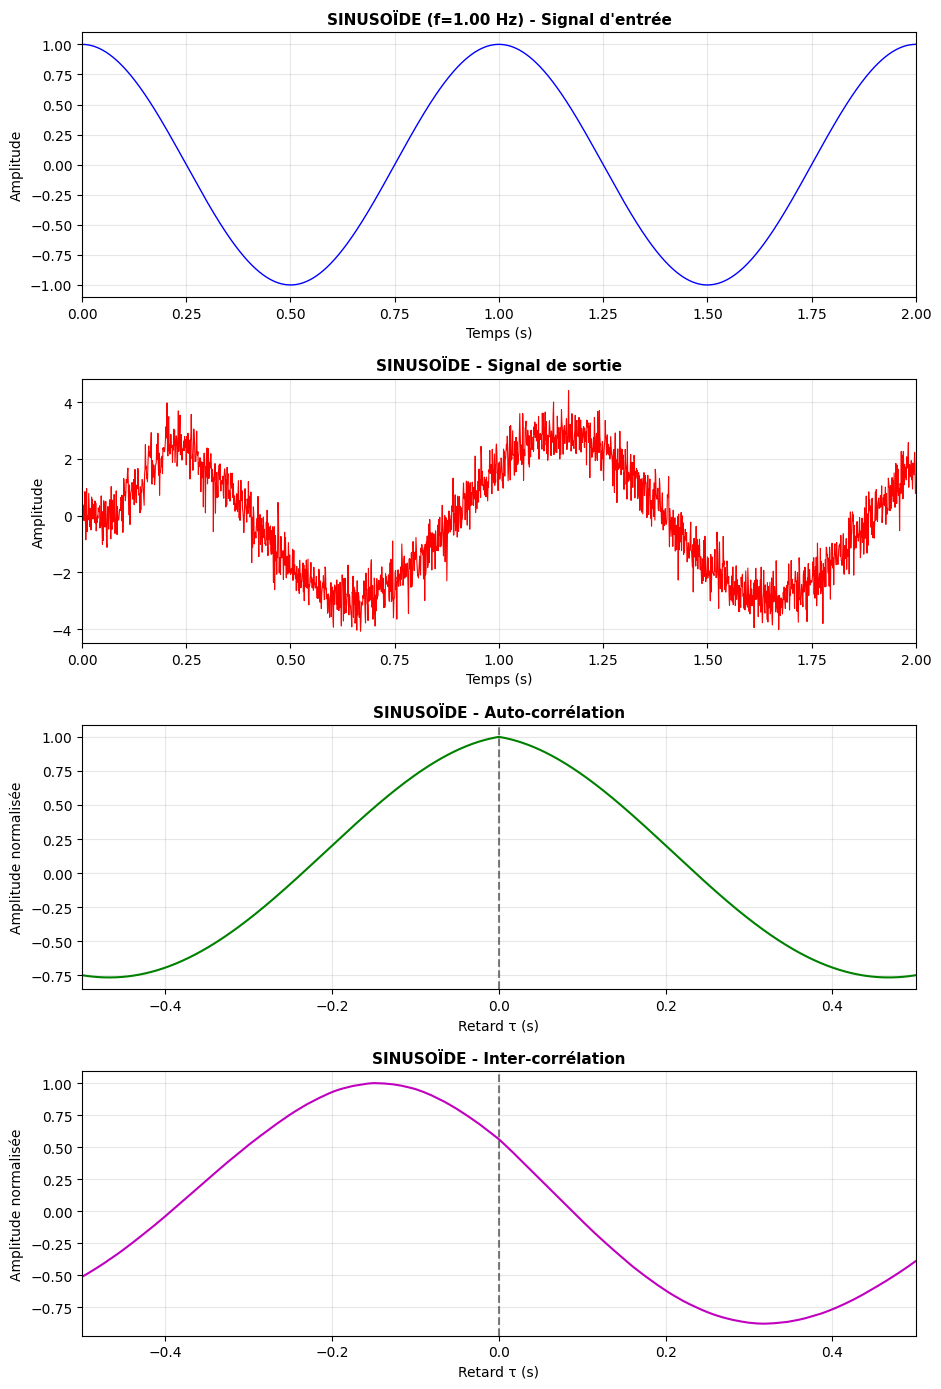

In [38]:
# Écrire votre code ici pour d)

# Signal sinusoidal
f_sin = w0 / (2*np.pi)  # 1 Hz
sin_input = np.cos(2 * np.pi * f_sin * t)

# Injecter dans la boîte noire
sin_output = blackbox_tp4.blackbox1(sin_input)

# AUTO-CORRÉLATION du signal sinusoidal
Rxx = np.correlate(sin_input, sin_input, mode='full')
Rxx_normalized = Rxx / np.max(np.abs(Rxx))

#INTER-CORRÉLATION entre le signal d'entrée et la sortie
Rxy = np.correlate(sin_input, sin_output, mode='full')
Rxy_normalized = Rxy / np.max(np.abs(Rxy))

dt = 1/fs
lags_xx = np.arange(-len(sin_input)+1, len(sin_input)) * dt  # Pour auto-corrélation
lags_xy = np.arange(-len(sin_input)+1, len(sin_output)) * dt  # Pour inter-corrélation

fig = plt.figure(figsize=(18, 14))

# Signal sinusoidal d'entrée
plt.subplot(4, 2, 2)
plt.plot(t, sin_input, 'b-', linewidth=1)
plt.title(f"SINUSOÏDE (f={f_sin:.2f} Hz) - Signal d'entrée", fontsize=11, fontweight='bold')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.xlim([0, 2])

# Signal sinusoïdal de sortie
plt.subplot(4, 2, 4)
plt.plot(t, sin_output, 'r-', linewidth=0.8)
plt.title("SINUSOÏDE - Signal de sortie", fontsize=11, fontweight='bold')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.xlim([0, 2])

# Auto-corrélation sinusoïde
plt.subplot(4, 2, 6)
plt.plot(lags_xx, Rxx_normalized, 'g-', linewidth=1.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.title("SINUSOÏDE - Auto-corrélation", fontsize=11, fontweight='bold')
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True, alpha=0.3)
plt.xlim([-0.5, 0.5])

# Inter-corrélation sinusoïde
plt.subplot(4, 2, 8)
plt.plot(lags_xy, Rxy_normalized, 'm-', linewidth=1.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.title("SINUSOÏDE - Inter-corrélation", fontsize=11, fontweight='bold')
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True, alpha=0.3)
plt.xlim([-0.5, 0.5])

plt.tight_layout()
plt.show()




**Interpretation**
Avec le chirp, nous pouvons distinguer 3 pics distinct (cibles), cependant, avec le signal sinusoidale, les pics sont ambigue et il est impossible de distinguer 2 cibles. (ou n'importe qu'elle évenements proche dans le temps). Le signal sinusoidale offre une mauvaise résolution temporelle, c'est pourquoi le signal chirp permet une meilleur analyse.

$\color{orange}{\text{e) [code]}}$  Déterminer la distance entre les cibles et le radar en considérant que l'unité de temps est donnée en microsecondes (ne pas oublier que le signal fait un aller-retour avec les cibles) $\color{red}{\textbf{(2pt/20)}}$



> **Note** : Nous supposons ici que le temps entre les maxima d'inter-corrélation correspond au délai réel entre les signaux. En temps normal, nous ne supposerions pas que le delai entre les maxima des deux interc-orrélations corresponde au délai exact, nous passerions par des tables qui associent pour notre système le délai d'intercorrélation au délai réel observé.


In [41]:
# Écrire votre code ici pour e)
def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
chirp_input = chirp_signal(f0, f1, t, T)

chirp_output = blackbox_tp4.blackbox1(chirp_input)

#INTER-CORRÉLATION entre le signal d'entrée et la sortie
Rxy = np.correlate(chirp_input, chirp_output, mode='full')
Rxy_normalized = Rxy / np.max(np.abs(Rxy))

dt = 1/fs
lags_xy = np.arange(-len(sin_input)+1, len(sin_output)) * dt  # Pour inter-corrélation

# Trouver tous les pics (cibles)
peaks, properties = find_peaks(Rxy_normalized, height=0.3, distance=50)

print(f"\nNombre de cibles détectées : {len(peaks)}")
print("\nPositions des pics d'inter-corrélation :")
for i, peak_idx in enumerate(peaks):
    peak_lag = lags[peak_idx]
    amplitude = Rxy_normalized[peak_idx]
    print(f"  Cible {i+1}: τ = {peak_lag:.6f} s, amplitude = {amplitude:.3f}")

# Conversion en microseconde et distance
c = 3e8  # Vitesse de la lumière dans l'air (m/s)
c_per_us = c * 1e-6  # Vitesse en mètres par microseconde = 300 m/μs

for i, peak_idx in enumerate(peaks):
    peak_lag_seconds = lags[peak_idx]

    delai_us = abs(peak_lag_seconds)

    distance_m = (delai_us * c_per_us) / 2

    print(f"\nCible {i+1} :")
    print(f"  Délai mesuré        : τ = {peak_lag_seconds:.6f}")
    print(f"  Délai interprété    : {delai_us:.6f} μs ")
    print(f"  Distance calculée   : {distance_m:.2f} m")



Nombre de cibles détectées : 3

Positions des pics d'inter-corrélation :
  Cible 1: τ = -0.200000 s, amplitude = 0.910
  Cible 2: τ = -0.150000 s, amplitude = 1.000
  Cible 3: τ = -0.100000 s, amplitude = 0.935

Cible 1 :
  Délai mesuré        : τ = -0.200000
  Délai interprété    : 0.200000 μs 
  Distance calculée   : 30.00 m

Cible 2 :
  Délai mesuré        : τ = -0.150000
  Délai interprété    : 0.150000 μs 
  Distance calculée   : 22.50 m

Cible 3 :
  Délai mesuré        : τ = -0.100000
  Délai interprété    : 0.100000 μs 
  Distance calculée   : 15.00 m


## $\color{#03fc9d}{\textbf{Précisions pour la remise:}}$

* Pour chaque exercice, répondre en ajoutant des cases de code ou de texte en dessous de la question.

* Remettez sur moodle un fichier `.ipynb` ainsi qu'une version `pdf` contenant seulement l'exercice 3) avec toutes les librairies et importations nécessaires pour que le code roule.

* Indiquer noms, matricules et numéro d'équipe au début du `notebook`.